<a href="https://colab.research.google.com/github/ne-hao/Seasonal_Agriculture_Analysis/blob/main/Seasonal_Agri_Platform_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [5]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


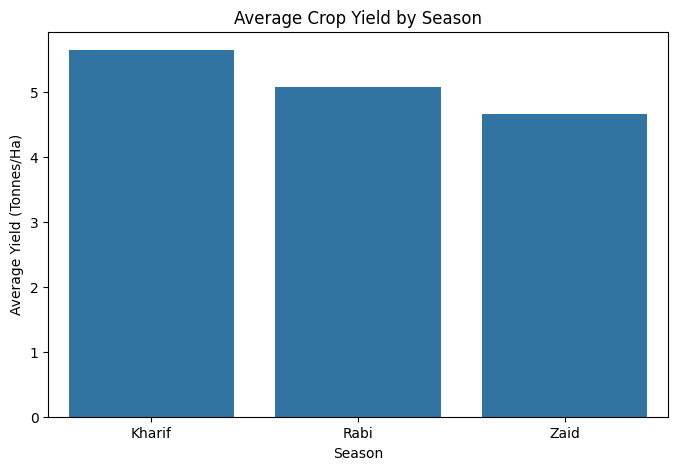

In [14]:
#Q1. Which season has the highest average crop yield?
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
print(season_yield)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)
plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

Season
Kharif    852.084205
Rabi      436.000124
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


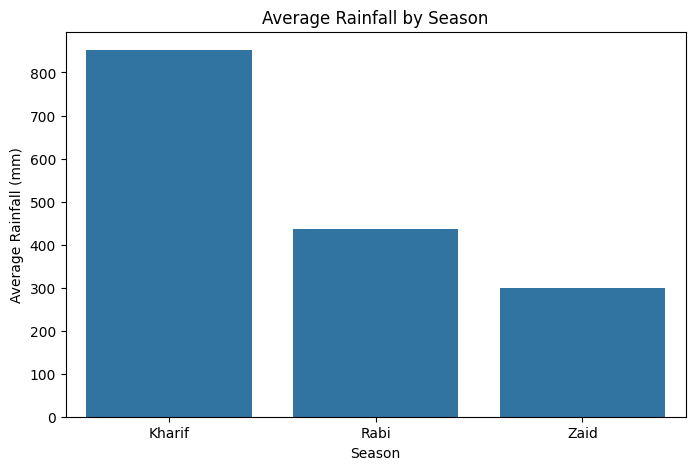

In [16]:
#Q2. How do rainfall and soil moisture vary across seasons?
#Rinfall
season_rainfall = df.groupby('Season')['Rainfall_mm'].mean()
print(season_rainfall)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_rainfall.index,
    y=season_rainfall.values
)
plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.show()

Season
Kharif    31.198410
Rabi      24.050620
Zaid      19.170085
Name: Soil_Moisture_pct, dtype: float64


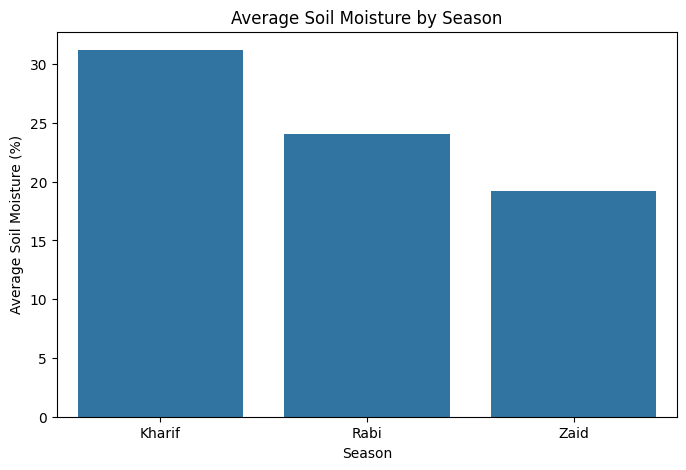

In [17]:
#Q2. How do rainfall and soil moisture vary across seasons?
#Soil Moisture
season_moisture = df.groupby('Season')['Soil_Moisture_pct'].mean()
print(season_moisture)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_moisture.index,
    y=season_moisture.values
)
plt.title('Average Soil Moisture by Season')
plt.xlabel('Season')
plt.ylabel('Average Soil Moisture (%)')
plt.show()

In [18]:
#Q2. How do rainfall and soil moisture vary across seasons?
#Comparing both
season_environment = df.groupby('Season')[
    ['Rainfall_mm', 'Soil_Moisture_pct']
].mean()
print(season_environment)

        Rainfall_mm  Soil_Moisture_pct
Season                                
Kharif   852.084205          31.198410
Rabi     436.000124          24.050620
Zaid     299.421784          19.170085


        Fertilizer_kg_ha  Pesticide_Litre_ha
Season                                      
Kharif        187.077965            5.079747
Rabi          185.407068            5.024690
Zaid          184.638047            5.171212


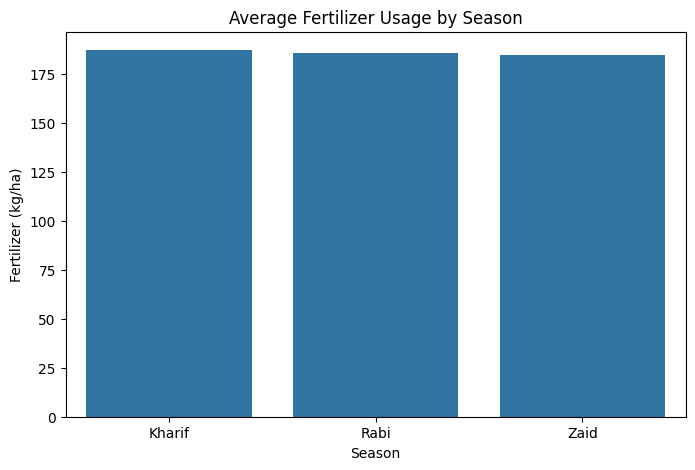

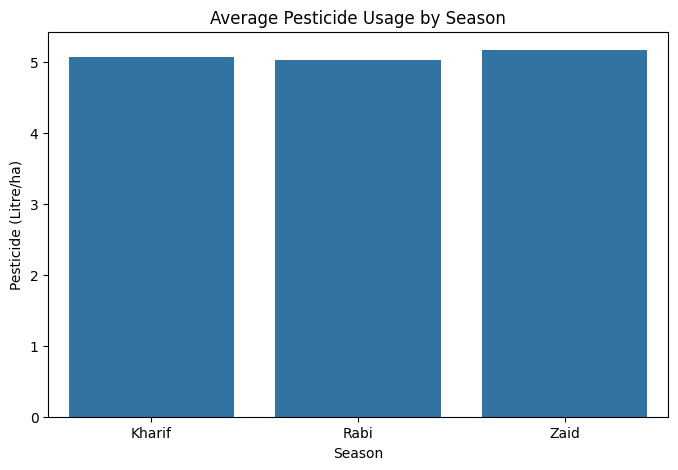

In [19]:
#Q3. How does fertilizer and pesticide usage differ between seasons?
season_resources = df.groupby('Season')[
    ['Fertilizer_kg_ha', 'Pesticide_Litre_ha']
].mean()
print(season_resources)

#Fertilizer Graph
plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_resources.index,
    y=season_resources['Fertilizer_kg_ha']
)
plt.title('Average Fertilizer Usage by Season')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')
plt.show()

#Pesticide Graph
plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_resources.index,
    y=season_resources['Pesticide_Litre_ha']
)
plt.title('Average Pesticide Usage by Season')
plt.xlabel('Season')
plt.ylabel('Pesticide (Litre/ha)')
plt.show()

Correlation between rainfall and yield: 0.03085301698272099


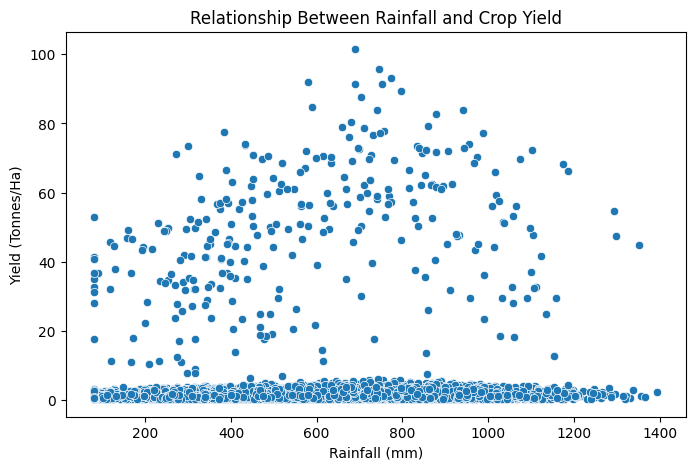

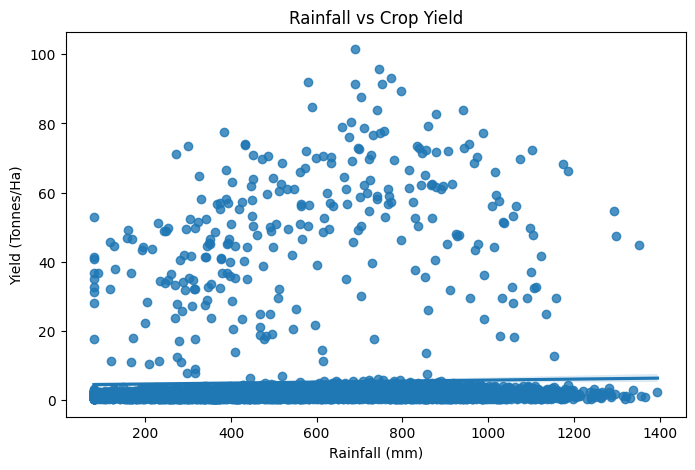

In [20]:
#Q4. Is there a relationship between rainfall and crop yield?
correlation = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])
print("Correlation between rainfall and yield:", correlation)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)
plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)
plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Correlation between soil moisture and yield: 0.01021016556535685


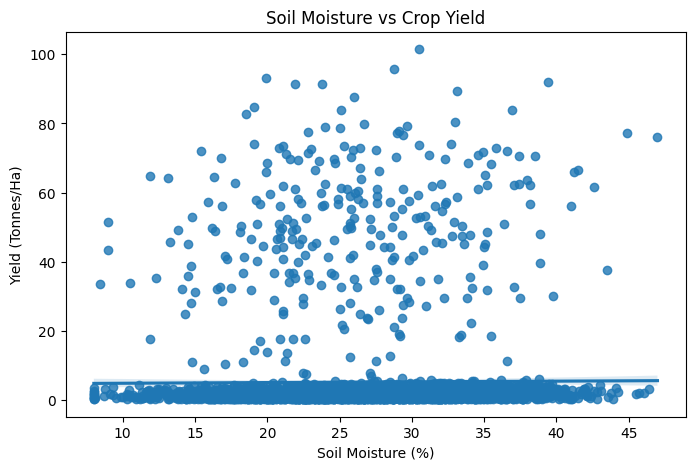

In [21]:
#Q5. Is soil moisture associated with higher crop yields?
correlation = df['Soil_Moisture_pct'].corr(df['Yield_Tonnes_Ha'])
print("Correlation between soil moisture and yield:", correlation)

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha'
)
plt.title('Soil Moisture vs Crop Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Average Revenue by Season:
Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


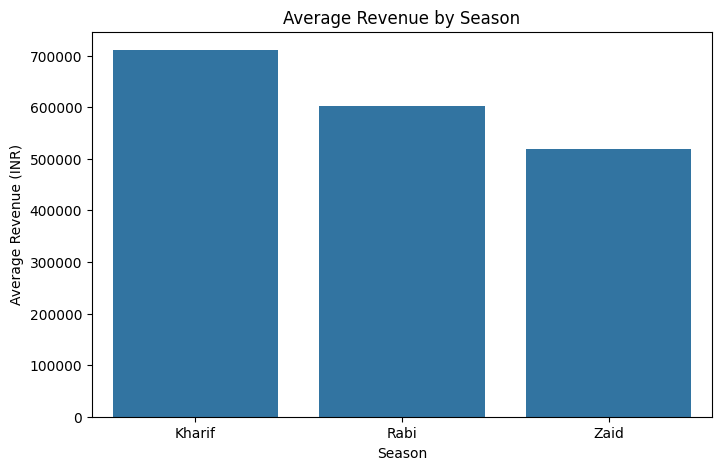

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


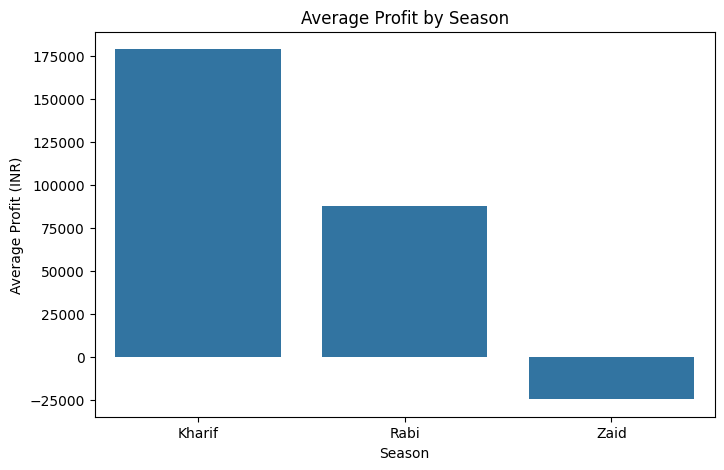

          Revenue_INR  Total_Cost_INR     Profit_INR
Season                                              
Kharif  710719.055649   531804.408094  178914.647555
Rabi    601526.048556   513836.578365   87689.470191
Zaid    519171.904040   543976.728956  -24804.824916


In [22]:
#Q6. Which season has the highest average revenue and profit?
#Average Revenue
season_revenue = df.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)
print("Average Revenue by Season:")
print(season_revenue)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values
)
plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.show()

#Average Profit
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)
print("Average Profit by Season:")
print(season_profit)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

#Comparing Both
economic_summary = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()
print(economic_summary)

         Crop  Season  Yield_Tonnes_Ha
0      Chilli  Kharif         1.731413
1      Chilli    Rabi         1.461615
2      Chilli    Zaid         1.177742
3      Cotton  Kharif         1.372804
4      Cotton    Rabi         1.192915
5      Cotton    Zaid         0.951648
6   Groundnut  Kharif         1.483646
7   Groundnut    Rabi         1.221445
8   Groundnut    Zaid         1.037778
9       Maize  Kharif         2.966410
10      Maize    Rabi         2.614913
11      Maize    Zaid         2.297590
12     Pulses  Kharif         1.036063
13     Pulses    Rabi         0.871887
14     Pulses    Zaid         0.652131
15       Rice  Kharif         2.707621
16       Rice    Rabi         2.333680
17       Rice    Zaid         1.900490
18  Sugarcane  Kharif        53.459120
19  Sugarcane    Rabi        43.940394
20  Sugarcane    Zaid        38.423922
21      Wheat  Kharif         2.255430
22      Wheat    Rabi         2.058814
23      Wheat    Zaid         1.748588
Season        Kharif     

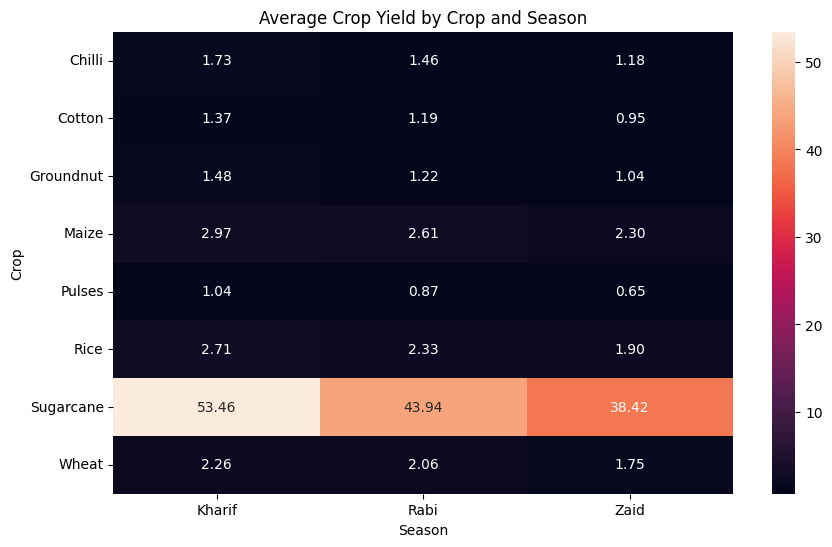

In [23]:
#Q7. Are seasonal yield patterns consistent across different crops?
crop_season_yield = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean().reset_index()
print(crop_season_yield)

#Creating a  pivot table
yield_pivot = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)
print(yield_pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(
    yield_pivot,
    annot=True,
    fmt='.2f'
)
plt.title('Average Crop Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120


<Figure size 1000x600 with 0 Axes>

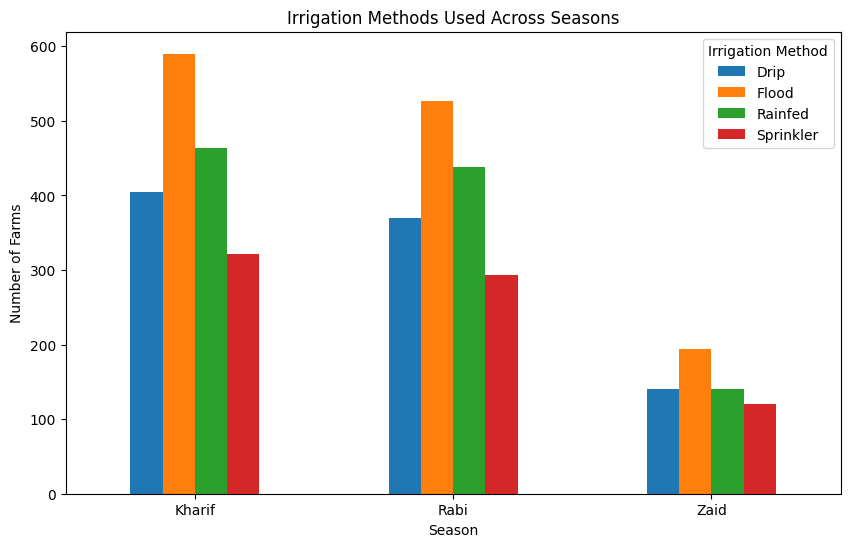

In [24]:
#Q8. Which irrigation method is most commonly used in each season?
irrigation_season = pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)
print(irrigation_season)

plt.figure(figsize=(10, 6))
irrigation_season.plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title('Irrigation Methods Used Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.show()

Yield_Tonnes_Ha       1.000000
Nitrogen_kg_ha        0.053867
Phosphorus_kg_ha      0.047821
Rainfall_mm           0.030853
Humidity_pct          0.011277
Soil_Moisture_pct     0.010210
Avg_Temperature_C     0.009349
Potassium_kg_ha       0.003836
Fertilizer_kg_ha      0.000562
Pesticide_Litre_ha   -0.007650
Sunlight_Hours_Day   -0.015362
Soil_pH              -0.020664
Name: Yield_Tonnes_Ha, dtype: float64


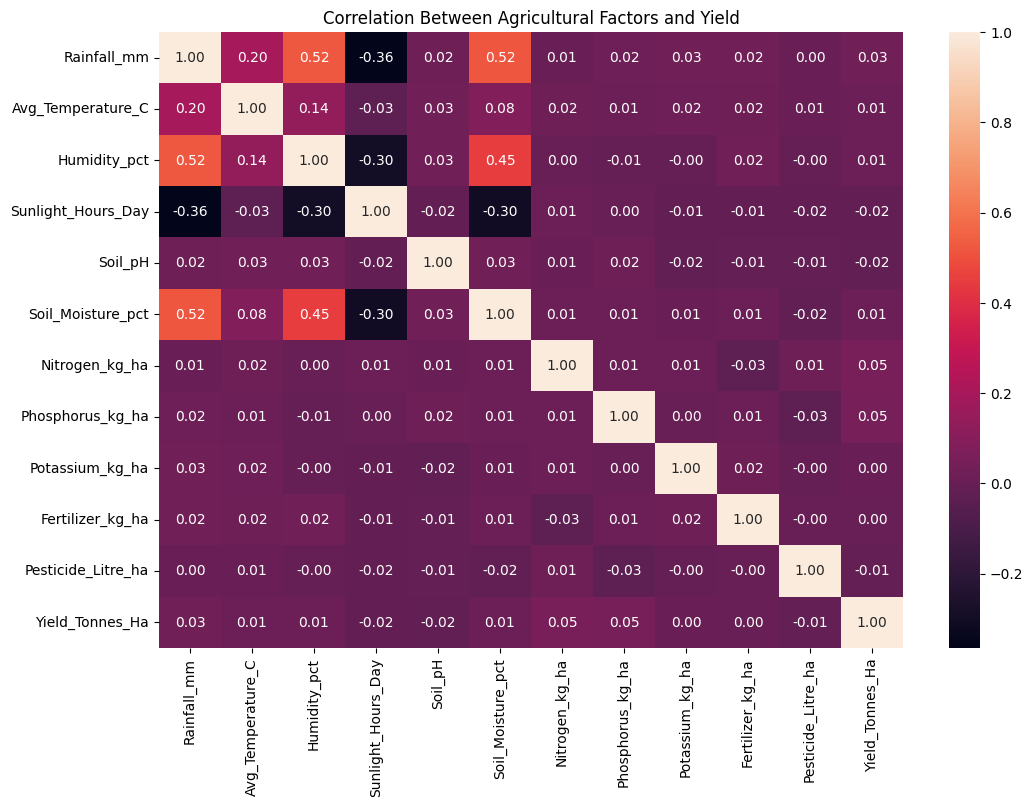

In [25]:
#Q9. What environmental factors are most strongly related to yield?
environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha'
]
correlation_matrix = df[environmental_columns].corr()
print(correlation_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False))

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)
plt.title('Correlation Between Agricultural Factors and Yield')
plt.show()